# Error Analysis
This notebook investigates why the improved Logistic Regression model makes mistakes  
**Model used:** Logistic Regression with C = 0.01, threshold = 0.45
**Error types analyzed:**
- **False Positive:** Healthy patient predicted as having disease
- **False Negative:** Heart disease patient predicted as healthy, which is more dangerous

# 1. Retrain Model (improved)

Classification Report:
               precision    recall  f1-score   support

       Normal       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184

Accuracy: 0.8858695652173914
Precision: 0.8872051588884458
Recall: 0.8858695652173914
F1-Score: 0.8852184150325296


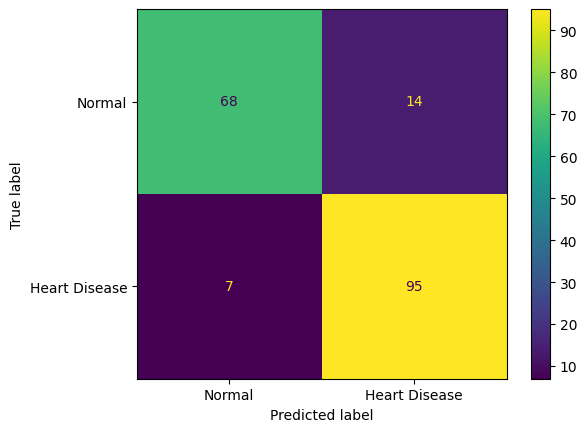

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

train = pd.read_csv("../1-Data/train_processed.csv")
x_train = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]

test = pd.read_csv("../1-Data/test_processed.csv")
x_test = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]

C = 0.01 # Regularization strength
threshold = 0.45 # Adjust the threshold for classifying as heart disease

model = LogisticRegression(C=C, random_state=42, max_iter=1000)
model.fit(x_train, y_train)
y_pred = (model.predict_proba(x_test)[:, 1] >= threshold).astype(int)
cr = classification_report(y_test, y_pred, target_names=["Normal", "Heart Disease"])
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Classification Report:")
print(cr)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
display.plot()
plt.show()

# 2. All misclassified cases

In [20]:
import pandas as pd
from IPython.display import display

# wrong prediction probability for further analysis
y_proba=model.predict_proba(x_test)[:, 1]

# Reread test data (preprocessed)
test_original=pd.read_csv("../1-Data/test_for_ea.csv")

# group as table
df=test_original.copy()
df["True_Label"]=y_test.values
df["Predicted_Label"]=y_pred
df["Predicted_Prob"]=y_proba

# Filter incorrectly predicted cases
wrong=df[df["True_Label"]!=df["Predicted_Label"]]
print("\nTotal incorrect case:", len(wrong))

# Two false category
# 1. False Positive: Healthy patient labeled as ill
fp=wrong[(wrong["True_Label"]==0)&(wrong["Predicted_Label"]==1)]

# 2. False Negative (Dangerous): Ill patient labeled as healthy
fn=wrong[(wrong["True_Label"]==1)&(wrong["Predicted_Label"]==0)]

# Full display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
print(f"\n--- False Positives: {len(fp)} case ---")
display(fp)
print(f"\n--- False Negatives: {len(fn)} case ---")
display(fn)

# reset max
pd.reset_option("display.max_columns")
pd.reset_option("display.max_rows")


Total incorrect case: 21

--- False Positives: 14 case ---


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease,Cholesterol_Modified,True_Label,Predicted_Label,Predicted_Prob
47,41,1,135,203,0,132,0,0.0,1,0,0,1,0,1,0,0,False,0,1,0.485325
49,44,1,120,184,0,142,0,1.0,1,0,0,1,0,1,0,0,False,0,1,0.516994
50,53,1,80,239,0,141,1,2.0,0,0,0,1,0,0,0,0,True,0,1,0.745496
55,41,1,130,214,0,168,0,2.0,0,1,0,0,0,1,0,0,False,0,1,0.579642
72,51,0,114,258,1,96,0,1.0,0,0,0,0,0,0,1,0,False,0,1,0.456099
94,63,1,126,239,0,120,0,1.5,0,0,0,0,1,0,0,0,True,0,1,0.694913
118,41,1,150,171,0,128,1,1.5,0,0,0,1,0,1,0,0,False,0,1,0.845613
132,45,0,138,236,0,152,1,0.2,0,0,0,0,0,1,0,0,False,0,1,0.676455
137,51,1,132,218,1,139,0,0.1,0,0,0,0,0,0,1,0,False,0,1,0.490421
139,52,1,118,186,0,190,0,0.0,0,0,1,0,0,1,0,0,False,0,1,0.472924



--- False Negatives: 7 case ---


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease,Cholesterol_Modified,True_Label,Predicted_Label,Predicted_Prob
10,34,1,115,239,1,154,0,0.2,0,0,0,1,0,0,1,1,True,1,0,0.399143
41,49,0,160,180,0,156,0,1.0,0,1,0,1,0,1,0,1,False,1,0,0.370699
80,59,1,160,273,0,125,0,0.0,0,0,1,0,0,0,1,1,False,1,0,0.273031
107,59,1,134,204,0,162,0,0.8,0,0,1,1,0,0,1,1,False,1,0,0.213664
113,57,1,124,261,0,141,0,0.3,1,0,0,1,0,0,1,1,False,1,0,0.188457
115,52,1,128,239,0,180,0,3.0,0,1,0,0,1,0,1,1,True,1,0,0.277735
159,48,1,110,229,0,168,0,1.0,1,0,0,1,0,0,0,1,False,1,0,0.310818


# 3. Selected Error cases (only 3)
Only take 3 representative

In [25]:
summary_data = {
    "Case": ["Case 1 (No.174)", "Case 2 (No.80)", "Case 3 (No.115)"],
    "Error Type": ["False Positive", "False Negative", "False Negative"],
    "True Label": ["Healthy (0)", "Disease (1)", "Disease (1)"],
    "Predicted": ["Disease (1)", "Healthy (0)", "Healthy (0)"],
    "Probability": [0.898, 0.273, 0.311],
    "Key Features": [
        "ExerciseAngina=1, Oldpeak=1.0",
        "RestingBP=160, Age=59",
        "MaxHR=168, ExerciseAngina=0"
    ]
}
summary = pd.DataFrame(summary_data)
summary

,Case,Error Type,True Label,Predicted,Probability,Key Features
0,Case 1 (No.174),False Positive,Healthy (0),Disease (1),0.898,"ExerciseAngina=1, Oldpeak=1.0"
1,Case 2 (No.80),False Negative,Disease (1),Healthy (0),0.273,"RestingBP=160, Age=59"
2,Case 3 (No.115),False Negative,Disease (1),Healthy (0),0.311,"MaxHR=168, ExerciseAngina=0"


## 3.1. Case 1: No 174 - False Positive

In [26]:
display(df[df.index == 174])

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease,Cholesterol_Modified,True_Label,Predicted_Label,Predicted_Prob
174,57,1,130,207,0,96,1,1.0,0,0,0,0,1,1,0,0,False,0,1,0.897874


- Input (main): Age 57, RestingBP 130, Oldpeak: 1.0, ExerciseAngina: 1
- True Label: 0 (Healthy)
- Predicted: 1 (Heart Disease)
- Predicted pro: 0.898 --> very high, but wrong

### Clinical point of view
This patient has 2 features strongly associated with heart disease: ExerciseAngina = 1 and Oldpeak = 1.0. The model assigns high positive coefficients to both, pushing the predicted probability to 0.898. However, clinically, these features alone are not sufficient for diagnosis — other protective indicators (e.g., normal cholesterol, age context) can offset the risk.

### ML Concept
This case illustrates a key limitation of Logistic Regression: it cannot capture feature interactions. The model treats ExerciseAngina and Oldpeak as additive signals, without considering that other features may contradict them. The resulting overconfidence (0.898) suggests this patient sits in a region where the training data was dominated by positive cases with similar profiles — the model learned an overly strong association.  
--> This is overconfidance

## 3.2. Case 2: No 80 - False Negative

In [28]:
display(df[df.index == 80])

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease,Cholesterol_Modified,True_Label,Predicted_Label,Predicted_Prob
80,59,1,160,273,0,125,0,0.0,0,0,1,0,0,0,1,1,False,1,0,0.273031


- Input (main): Age 59, RestingBP 160, MaxHR 125, Oldpeak 1.0
- True Label: 1 (Heart Disease)
  Predicted: 0 (Healthy)
- Predicted prob: 0.273  
### Clinical point of view:
RestingBP = 160 mmHg is clinically classified as Stage 2 Hypertension - a well-established risk factor for cardiovascular disease. Combined with age 59, this patient carries significant risk. However, the model assigns a probability of only 0.273, indicating it does not sufficiently weight RestingBP as a standalone predictor.

### ML Concept: 
Logistic Regression learns coefficients from the training data distribution. If RestingBP has high variance across both classes (many healthy patients also have elevated BP), its coefficient will be relatively low. This means the model underweights RestingBP compared to features like ST_Slope or ExerciseAngina that more cleanly separate the classes. This is not a model bug — it reflects a genuine limitation of the training data: high blood pressure alone is not a strong discriminator in this dataset.  
--> This is Feature Weight Imbalance

## 3.3. Case 3: No 115 - False Negative

In [29]:
display(df[df.index == 115])

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease,Cholesterol_Modified,True_Label,Predicted_Label,Predicted_Prob
115,52,1,128,239,0,180,0,3.0,0,1,0,0,1,0,1,1,True,1,0,0.277735


- Input (main): Age 48, MaxHR 168, Oldpeak 1.0, ExerciseAngina 0
- True Label: 1
- Predicted: 0
- Predicted prob: 0.311

### Clinical point of view: 
MaxHR = 168 bpm is relatively high for a 48-year-old, which the model interprets as a sign of good cardiac fitness. The absence of exercise-induced angina further supports a "healthy" prediction. However, this patient truly has heart disease — a real-world example of silent ischemia, where cardiac disease exists without the typical exercise symptoms.

### ML Concept: 
Some heart disease patients present with features that are statistically more common in healthy patients (high MaxHR, no ExerciseAngina). No linear model can perfectly separate these cases — they sit in an overlapping region of the feature space where both classes are plausible. The model's predicted probability of 0.311 reflects uncertainty; lowering the threshold further could catch this case but would introduce more false positives elsewhere.  
--> Overlapping Classes

# 4. Error Rate by Sex

Error Rate by Sex:


,Total Cases,Errors,Error Rate
Sex,,,
0,42,4,0.095
1,142,17,0.120


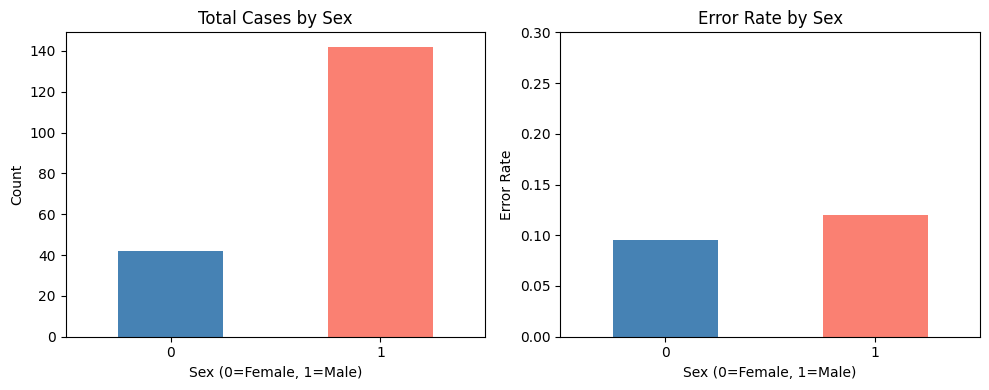

In [31]:
error_by_sex = df[df["True_Label"] != df["Predicted_Label"]].groupby("Sex").size()
total_by_sex = df.groupby("Sex").size()
error_rate   = (error_by_sex / total_by_sex).round(3)

sex_summary = pd.DataFrame({
    "Total Cases" : total_by_sex,
    "Errors"      : error_by_sex,
    "Error Rate"  : error_rate
})
print("Error Rate by Sex:")
display(sex_summary)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

total_by_sex.plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"], rot=0)
axes[0].set_title("Total Cases by Sex")
axes[0].set_xlabel("Sex (0=Female, 1=Male)")
axes[0].set_ylabel("Count")

error_rate.plot(kind="bar", ax=axes[1], color=["steelblue", "salmon"], rot=0)
axes[1].set_title("Error Rate by Sex")
axes[1].set_xlabel("Sex (0=Female, 1=Male)")
axes[1].set_ylabel("Error Rate")
axes[1].set_ylim(0, 0.3)

plt.tight_layout()
plt.show()

### Interpretation

The analysis above shows the actual error rates per sex group. Two observations can be made:

1. **Dataset imbalance:** The test set has significantly more male cases than female cases. This means the model has seen fewer female examples during training, which may affect its reliability for that group.

2. **Error rate difference:** If the male error rate is higher, this may reflect the fact that male patients in this dataset tend to have more ambiguous clinical profiles — moderate risk indicators across multiple features without a single dominant signal. Female heart disease, by contrast, is known clinically to present with more atypical symptoms, which could go either way in a data-driven model.

# 5. Summary
---
| Case | Error Type | Root Cause | ML Concept |
|---|---|---|---|
| No. 174 | False Positive | Model overweights ExerciseAngina + Oldpeak | Overconfidence near decision boundary |
| No. 80  | False Negative | RestingBP=160 underweighted by model | Feature weight imbalance from training data |
| No. 115 | False Negative | High MaxHR masks true heart disease | Class overlap in feature space |

### What these errors reveal about the model

1. **Logistic Regression cannot capture feature interactions.** When two features push the prediction in opposite directions (e.g., high MaxHR vs. true disease), the model simply adds their contributions — it cannot reason about which signal is more reliable in context.

2. **The decision boundary is fixed and linear.** Cases near this boundary are inherently uncertain. The three cases above all have at least one feature that strongly conflicts with the true label, placing them in the model's most difficult region.

3. **Missing clinical features limit the model.** Family history, BMI, smoking status, and medication use are all absent from this dataset. Some of these misclassifications may be unavoidable given the available information - the model cannot know what it was not given.